# Module 1 - First circuit

In [97]:
import os
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit.visualization import array_to_latex, plot_histogram
from IPython.display import display


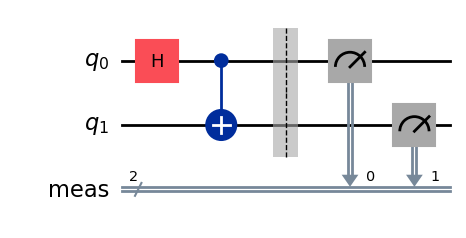

In [76]:
# Define a quantum circuit with 2 qubits
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw()

display(bell.draw('mpl'))


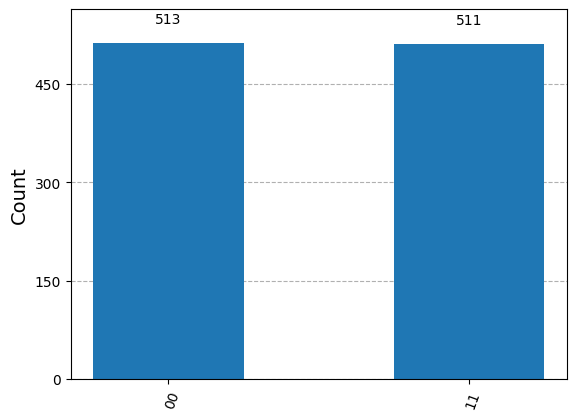

In [77]:
#simulator = Aer.get_backend('qasm_simulator')

simulator = AerSimulator()
compiled_circuit = transpile(bell, simulator)
job = simulator.run(compiled_circuit)
result = job.result()

plot_histogram(result.get_counts(compiled_circuit))

In [78]:
service = QiskitRuntimeService()
print (service.backends()) 

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_kyiv')>, <IBMBackend('ibm_sherbrooke')>]


In [79]:
backend = service.least_busy(simulator=False, operational=True)
print (f'Least busy backend: {backend.name}')
print (f'  Pending jobs: {backend.status().pending_jobs}')
print (f'  Number of qubits: {len(backend.properties().qubits)}')


Least busy backend: ibm_brisbane
  Pending jobs: 8
  Number of qubits: 127


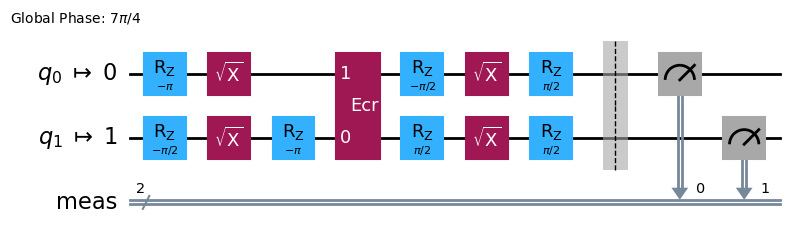

In [ ]:

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)
 
isa_bell.draw("mpl", idle_wires=False)

In [ ]:
sampler = Sampler(backend)
job = sampler.run([isa_bell], shots=1000)               # notice qc in a list


In [95]:
print (f'Job status: {job.status()}')

if job.status() == 'DONE':
    result = job.result()
    print(f">>> Result: {result}")
    counts = result[0].data.meas.get_counts()
    print(f"Counts: {counts}")     

Job status: DONE
>>> Result: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-03-23 19:47:14', stop='2025-03-23 19:47:15', size=1000>)])}, 'version': 2})
Counts: {'00': 485, '11': 480, '01': 22, '10': 13}


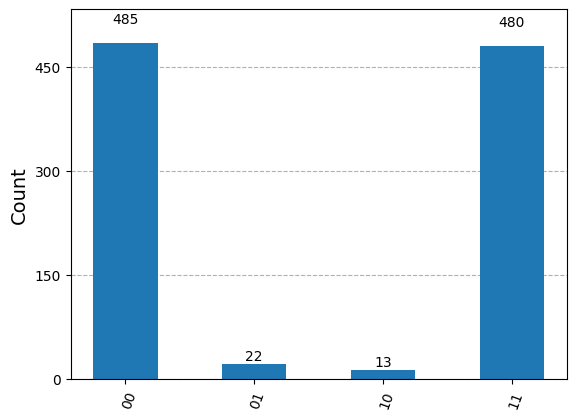

In [96]:
plot_histogram(result[0].data.meas.get_counts())